C:\Users\wurglerr\AppData\Local\Temp\ipykernel_24764\224901762.py:46: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


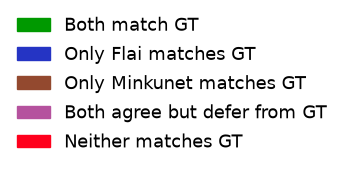

In [64]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# 1. Dictionnaire d'entrée (Couleur: Texte)
"""legend_data = {
    "#994c33": "Ground",
    "#009900": "Vegetation",
    "#ffa800": "Roof/Building",
    "#b3b3b3": "Facade",
    "#3333cc": "Roof Structure",
    "#ff0033": "Vehicle",
    "#af549d": "Other",
}"""

legend_data = {
    "#009900": "Both match GT",
    "#2534C4": "Only Flai matches GT",
    "#93492F": "Only Minkunet matches GT",
    "#B5529E": "Both agree but defer from GT",
    "#FF001C": "Neither matches GT" 
}

# 2. Création de la figure avec fond noir
fig, ax = plt.subplots(figsize=(1, 1))

# 3. Génération des rectangles colorés pour la légende
handles = [
    mpatches.Patch(color=color, label=text) for color, text in legend_data.items()
]

# 4. Configuration de la légende Matplotlib (Texte en blanc)
ax.legend(
    handles=handles,
    loc="center",  # Centre la légende dans la figure
    frameon=False,  # Supprime la bordure autour de la légende
    handlelength=1.8,  # Longueur des rectangles colorés
    handleheight=0.7,  # Hauteur des rectangles colorés
    labelspacing=0.6,  # Espace vertical entre les lignes
    fontsize=13,  # Taille du texte  # Force la couleur du texte en blanc
)

# 5. Nettoyage de l'affichage (suppression des axes)
ax.axis("off")

# 6. Affichage et sauvegarde
plt.tight_layout()
plt.show()


Saved: D:\Raphael\preentation\image\titre.png


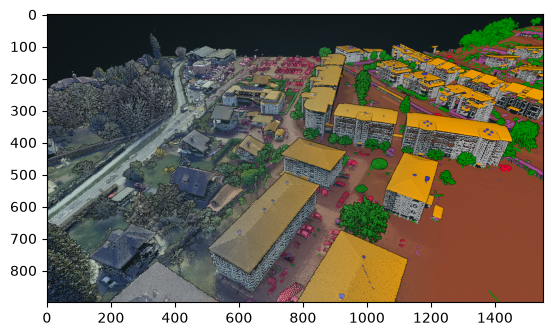

In [ ]:
from PIL import Image
import numpy as np

# ===========================
# Parameters
# ===========================
RGB_PATH = r"D:\Raphael\preentation\image\galerie\Capture d'écran 2026-07-21 155917.png"
CLASS_PATH = r"D:\Raphael\preentation\image\galerie\Capture d'écran 2026-07-21 155941.png"
OUTPUT_PATH = r"D:\Raphael\preentation\image\titre2.png"

# Crop rectangle (left, top, right, bottom)
# Set to None to disable cropping.
# Example values:
CROP = (320, 100, 1870, 1000)

# Transition limits as fraction of width
START_BLEND = 0.30
END_BLEND = 0.80

# ===========================
# Load
# ===========================
rgb = Image.open(RGB_PATH).convert("RGB")
cls = Image.open(CLASS_PATH).convert("RGB")

# Optional crop
if CROP is not None:
    rgb = rgb.crop(CROP)
    cls = cls.crop(CROP)

# Ensure same size
assert rgb.size == cls.size

rgb = np.asarray(rgb, dtype=np.float32)
cls = np.asarray(cls, dtype=np.float32)

h, w = rgb.shape[:2]

# ===========================
# Build blending mask
# ===========================
mask = np.zeros(w, dtype=np.float32)

x0 = int(START_BLEND * w)
x1 = int(END_BLEND * w)

mask[:x0] = 0.0
mask[x1:] = 1.0
mask[x0:x1] = np.linspace(0.0, 1.0, x1 - x0)

mask = np.tile(mask, (h, 1))
mask = mask[..., None]  # H x W x 1

# ===========================
# Blend
# ===========================
result = rgb * (1.0 - mask) + cls * mask
result = np.clip(result, 0, 255).astype(np.uint8)

Image.fromarray(result).save(OUTPUT_PATH)

plt.imshow(result)
print("Saved:", OUTPUT_PATH)

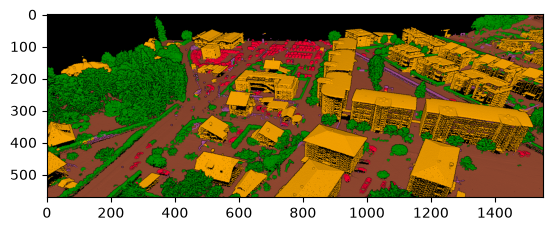

In [52]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# ===========================
# Parameters
# ===========================
RGB_PATH = r"D:\Raphael\preentation\image\galerie\Capture d'écran 2026-07-31 103236.png"
OUTPUT_PATH = r"D:\Raphael\preentation\image\Pointly.png"

# Crop rectangle (left, top, right, bottom)
# Set to None to disable cropping.
# Example values:
rgb = Image.open(RGB_PATH).convert("RGB")
CROP = (320, 100, 1870, 672)
if CROP is not None:
    rgb = rgb.crop(CROP)

rgb.save(OUTPUT_PATH)

plt.imshow(rgb)
#print("Saved:", OUTPUT_PATH)

In [53]:
import os
from PIL import Image, ImageDraw, ImageFont

dir = r"D:\Raphael\preentation\image"

image_paths = [
    "Pointly.png", "Flai.png", "Classical.png", "Simon.png",
    "Minkunet.png", "Combined.png", "MulticlassRF.png",
]

legend_classes = {
    "#994c33": "Ground",
    "#009900": "Vegetation",
    "#ffa800": "Roof/Building",
    "#b3b3b3": "Facade",
    "#3333cc": "Roof Structure",
    "#ff0033": "Vehicle",
    "#af549d": "Other",
}

images = []
for path in image_paths:
    full_path = os.path.join(dir, path)
    img = Image.open(full_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    try:
        font_title = ImageFont.truetype("arial.ttf", 30)
        font_legend = ImageFont.truetype("arial.ttf", 18)
    except IOError:
        font_title = ImageFont.load_default()
        font_legend = ImageFont.load_default()

    text_title = os.path.splitext(path)[0]
    pos_title = (15, 15)
    bbox_title = draw.textbbox(pos_title, text_title, font=font_title)
    padding_title = 6
    bg_title = [bbox_title[0]-padding_title, bbox_title[1]-padding_title,
                bbox_title[2]+padding_title, bbox_title[3]+padding_title]
    draw.rectangle(bg_title, fill="black")
    draw.text(pos_title, text_title, fill="white", font=font_title)

    start_y = img.height - 40 - (len(legend_classes) * 26)
    start_x = 15
    max_text_width = 0
    for text in legend_classes.values():
        left, top, right, bottom = draw.textbbox((0, 0), text, font=font_legend)
        max_text_width = max(max_text_width, right - left)
    bg_legend_width = 10 + 16 + 10 + max_text_width + 15
    bg_legend_height = (len(legend_classes) * 26) + 14
    bg_legend_rect = [start_x, start_y, start_x+bg_legend_width, start_y+bg_legend_height]
    draw.rectangle(bg_legend_rect, fill="black")

    current_y = start_y + 10
    for hex_color, text in legend_classes.items():
        square_rect = [start_x+10, current_y, start_x+10+16, current_y+16]
        draw.rectangle(square_rect, fill=hex_color)
        text_pos = (start_x+10+16+10, current_y-2)
        draw.text(text_pos, text, fill="white", font=font_legend)
        current_y += 26

    images.append(img)

# --- FIX: build ONE shared palette that reserves the exact legend colors ---
legend_rgb = [
    tuple(int(h.lstrip("#")[i:i+2], 16) for i in (0, 2, 4))
    for h in legend_classes
]
n_reserved = len(legend_rgb)

# Learn a good background palette from ALL frames combined, leaving room
# for the reserved legend colors.
combo = Image.new("RGB", (images[0].width * len(images), images[0].height))
for i, im in enumerate(images):
    combo.paste(im, (i * im.width, 0))

base = combo.quantize(colors=256 - n_reserved, method=Image.Quantize.MEDIANCUT)
palette = base.getpalette()[: (256 - n_reserved) * 3]
for r, g, b in legend_rgb:
    palette += [r, g, b]
while len(palette) < 256 * 3:
    palette += [0, 0, 0]

shared_palette_im = Image.new("P", (1, 1))
shared_palette_im.putpalette(palette)

# Map every frame onto the SAME palette, no dithering (flat colors -> exact match).
quantized = [
    im.quantize(palette=shared_palette_im, dither=Image.Dither.NONE)
    for im in images
]

quantized[0].save(
    r"D:\Raphael\preentation\image\animation.gif",
    save_all=True,
    append_images=quantized[1:],
    duration=1500,
    loop=0,
    lossless=True,
)

print("GIF avec titre et légende des classes créé avec succès !")

GIF avec titre et légende des classes créé avec succès !


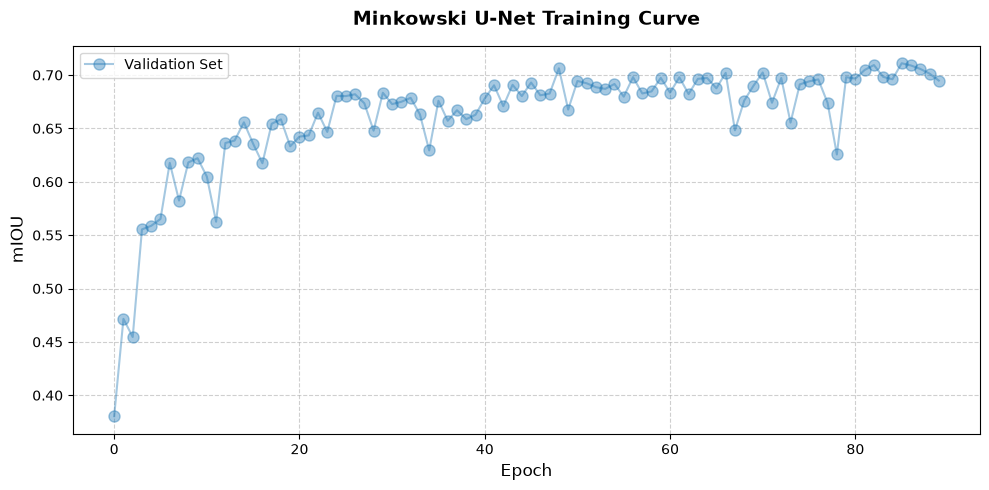

In [61]:
import io
import matplotlib.pyplot as plt
import pandas as pd

# Données CSV fournies
csv_data = """Wall time,Step,Value
1783608869.2880368,0,0.3804122805595398
1783612737.1571438,1,0.47158923745155334
1783616291.71959,2,0.4545784294605255
1783619864.3824406,3,0.5553984642028809
1783623423.2666364,4,0.5587789416313171
1783626988.739444,5,0.5651995539665222
1783630557.7200983,6,0.6177025437355042
1783634137.0569942,7,0.5824041962623596
1783637699.1604643,8,0.6181219220161438
1783641246.4395437,9,0.6220623254776001
1783644818.1550095,10,0.6049392223358154
1783648380.7416875,11,0.5626093745231628
1783651936.9605782,12,0.636326253414154
1783655494.2918718,13,0.6386133432388306
1783659047.2062173,14,0.6556910276412964
1783662612.8215308,15,0.6355922222137451
1783666175.8818893,16,0.6173793077468872
1783669743.9939961,17,0.654386579990387
1783673300.2262082,18,0.6584932804107666
1783676865.495175,19,0.6332442760467529
1783680428.9593089,20,0.6423273682594299
1783683990.6205788,21,0.6434052586555481
1783687552.4554174,22,0.6647598147392273
1783691106.839805,23,0.6466963291168213
1783694679.7463067,24,0.6804652810096741
1783698228.013483,25,0.6802642345428467
1783701789.0504246,26,0.681985080242157
1783705363.695468,27,0.6735401749610901
1783708924.5784094,28,0.6478701233863831
1783712493.25325,29,0.6833809018135071
1783716057.365302,30,0.6727467179298401
1783719605.7906585,31,0.6749637722969055
1783723156.8996763,32,0.6786133646965027
1783726720.6466157,33,0.6631359457969666
1783730270.1436725,34,0.6293706297874451
1783733837.9634202,35,0.6758747100830078
1783737398.7302995,36,0.6571654677391052
1783740963.308082,37,0.6670178174972534
1783744531.2757819,38,0.6586472988128662
1783748096.9209166,39,0.6627853512763977
1783751660.7614791,40,0.6780574321746826
1783755214.6036472,41,0.6903733611106873
1783758770.7716546,42,0.6708460450172424
1783762330.2530954,43,0.6908493638038635
1783765893.4122012,44,0.6802712678909302
1783769453.2074428,45,0.6929616928100586
1783773008.2408633,46,0.6810173988342285
1783776562.5542526,47,0.6826522946357727
1783780128.6592174,48,0.7063121795654297
1783783695.4773772,49,0.6676251292228699
1783787246.7814236,50,0.6944328546524048
1783790794.9756086,51,0.6922604441642761
1783794346.287469,52,0.6885912418365479
1783797920.3531516,53,0.6870192885398865
1783801481.3275955,54,0.6916132569313049
1783805041.615624,55,0.6797273755073547
1783808600.452833,56,0.6979972124099731
1783812159.1822639,57,0.682722806930542
1783815723.064367,58,0.6846451759338379
1783819283.0742486,59,0.697322428226471
1783822845.4003284,60,0.6834976077079773
1783826399.0206587,61,0.6978698372840881
1783829960.2319477,62,0.6821671724319458
1783833513.0394275,63,0.6964473724365234
1783837075.9302733,64,0.6972326040267944
1783840636.8662586,65,0.6875984072685242
1783844210.2291863,66,0.7020267844200134
1783847772.5543668,67,0.6482076048851013
1783851340.1482742,68,0.6760284304618835
1783854913.1131642,69,0.6899209022521973
1783858484.5121877,70,0.7023666501045227
1783862054.9074495,71,0.6740446090698242
1783865617.3785865,72,0.6972406506538391
1783869176.070369,73,0.6554422378540039
1783872735.766184,74,0.6912290453910828
1783876303.86978,75,0.6940407752990723
1783879853.387813,76,0.6959167122840881
1783883427.0983744,77,0.6738601326942444
1783887013.183775,78,0.6255701184272766
1783890565.9927068,79,0.6979551911354065
1783894123.1135979,80,0.6966812014579773
1783897687.1862888,81,0.7047574520111084
1783901240.8030744,82,0.7093413472175598
1783904805.6011434,83,0.6982691884040833
1783908364.9166996,84,0.696051299571991
1783911926.4106166,85,0.7110292911529541
1783915488.922466,86,0.7089266180992126
1783919062.7030947,87,0.7057581543922424
1783922642.6867187,88,0.7013748288154602
1783926219.409965,89,0.6948219537734985"""

# Charger les données dans un DataFrame
df = pd.read_csv(io.StringIO(csv_data))

# Configurer le style du graphique
plt.figure(figsize=(10, 5))
plt.grid(True, linestyle="--", alpha=0.6)

# Tracer les données brutes (en fonction de 'Step')
plt.plot(
    df["Step"],
    df["Value"],
    label="Validation Set",
    color="#1f77b4",
    alpha=0.4,
    marker="o",
    markersize=8,
)

# Optionnel : Calculer et tracer une moyenne mobile pour lisser la courbe
df["Smoothed_Value"] = df["Value"].rolling(window=5, min_periods=1).mean()

# Personnalisation des axes et du titre
plt.title(
    "Minkowski U-Net Training Curve",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("mIOU", fontsize=12)
plt.legend()

# Ajuster la mise en page
plt.tight_layout()

# Afficher le graphique
plt.show()
